# Opciones Asiáticas y con Barrera — Monte Carlo

Edgardo y Sara

## Configuración inicial y simulación de trayectorias

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)   # reproducibilidad

# Parámetros base
S0    = 670
K     = 680
r     = 0.04
sigma = 0.17
N     = 30          # número de días
T     = N / 365     # tiempo al vencimiento en años
M     = 10_000      # número de simulaciones
dt    = T / N

# Simulación de trayectorias (movimiento browniano geométrico)
Z        = np.random.standard_normal((M, N))
retornos = (r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
S_paths  = S0 * np.exp(np.cumsum(retornos, axis=1))
S_paths  = np.insert(S_paths, 0, S0, axis=1)

print(f"Trayectorias simuladas: {M:,}")
print(f"Pasos por trayectoria : {N}  (T = {T:.4f} años)")
print(f"Forma de la matriz    : {S_paths.shape}")

Trayectorias simuladas: 10,000
Pasos por trayectoria : 30  (T = 0.0822 años)
Forma de la matriz    : (10000, 31)


---
## 1. Precios: Opción Asiática vs. Vanilla vs. Black-Scholes

In [2]:
# Payoffs
ST      = S_paths[:, -1]           # precio final
S_media = S_paths.mean(axis=1)     # promedio de cada trayectoria

europea = np.exp(-r * T) * np.maximum(ST - K, 0)
asiatica = np.exp(-r * T) * np.maximum(S_media - K, 0)

# Precio analítico Black-Scholes
d1     = (np.log(S0 / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
d2     = d1 - sigma * np.sqrt(T)
bs_call = S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

print(f"Precio Asiática  (MC) : ${asiatica.mean():.4f}")
print(f"Precio Europea   (MC) : ${europea.mean():.4f}")
print(f"Precio Black-Scholes  : ${bs_call:.4f}")
print(f"\nDiferencia (Europea - Asiática): ${europea.mean() - asiatica.mean():.4f}")

Precio Asiática  (MC) : $4.0437
Precio Europea   (MC) : $9.6304
Precio Black-Scholes  : $9.5820

Diferencia (Europea - Asiática): $5.5867


---
## Gráfica: Trayectorias y distribución de precios

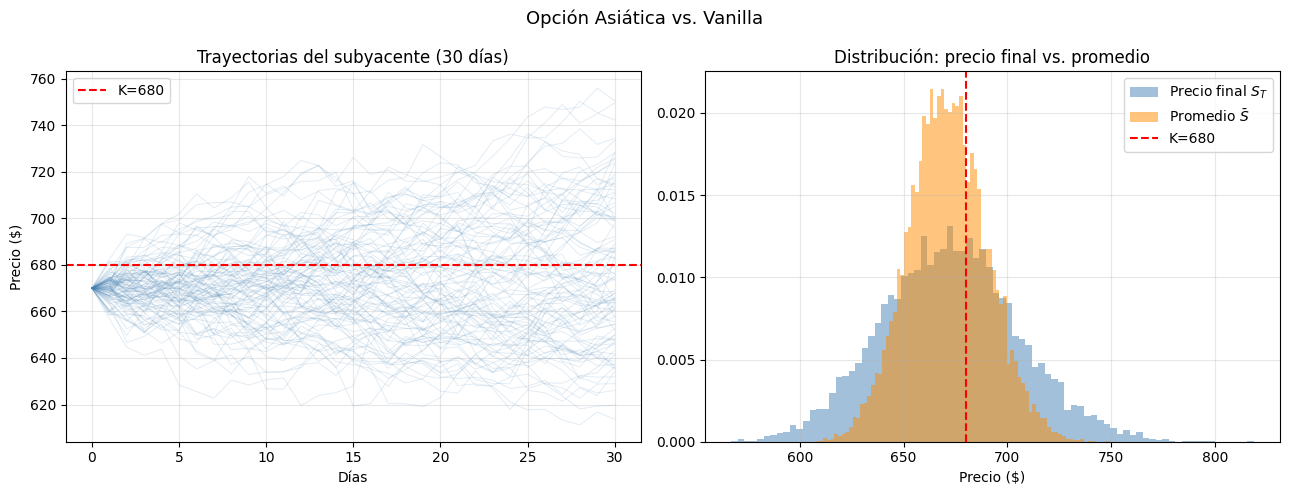

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Trayectorias simuladas
for i in range(100):
    axes[0].plot(S_paths[i], alpha=0.15, linewidth=0.7, color='steelblue')
axes[0].axhline(K, color='red', linestyle='--', linewidth=1.5, label=f'K={K}')
axes[0].set_title('Trayectorias del subyacente (30 días)')
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Precio ($)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Distribución: precio final vs. promedio
axes[1].hist(ST,      bins=80, density=True, alpha=0.5,
             color='steelblue',  label='Precio final $S_T$')
axes[1].hist(S_media, bins=80, density=True, alpha=0.5,
             color='darkorange', label='Promedio $\\bar{S}$')
axes[1].axvline(K, color='red', linestyle='--', label=f'K={K}')
axes[1].set_title('Distribución: precio final vs. promedio')
axes[1].set_xlabel('Precio ($)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opción Asiática vs. Vanilla', fontsize=13)
plt.tight_layout()
plt.show()

---
## Pregunta 1: La opción asiática es más barata que la vanilla. ¿Siempre es así? ¿Puedes pensar en algún caso donde fueran igual de caras?



Casi siempre la asiática es más barata**, pero hay casos donde ambas convergen al mismo precio.

#### ¿Por qué suele ser más barata?

La clave está en la **varianza**. El promedio de los precios $\bar{S}$ tiene menor varianza que el precio final $S_T$:

$$\text{Var}(\bar{S}) < \text{Var}(S_T)$$

Esto se aprecia claramente en la gráfica de distribuciones: la distribución de $\bar{S}$ (naranja) es más angosta y está más centrada que la de $S_T$ (azul). Una menor dispersión implica:
- Menos probabilidad de que $\bar{S}$ alcance valores muy altos (colas más cortas).
- Los payoffs ITM extremos son menos frecuentes.
- El precio esperado descontado es menor.

#### ¿Cuándo serían igual de caras?

Existen al menos dos casos límite donde la asiática ≈ vanilla:

| Caso | Razón |
|------|-------|
| **N = 1** (solo un período) | El promedio es el único precio observado: $\bar{S} = S_T$. Ambas opciones tienen idéntico payoff. |
| **σ → 0** (volatilidad nula) | El activo crece deterministamente a la tasa $r$. El promedio y el precio final convergen al mismo valor. |
| **T → 0** (vencimiento inmediato) | Con plazo casi nulo, la trayectoria es casi plana: $\bar{S} \approx S_T \approx S_0$. |

En la práctica, conforme N aumenta o σ crece, la brecha entre asiática y vanilla se amplía, pues el promedio "suaviza" cada vez más las fluctuaciones extremas que generarían payoffs grandes en la vanilla.

---
## 2. Opciones con Barrera: Up-and-Out e Up-and-In

In [4]:
B_up  = 710
S_max = S_paths.max(axis=1)   # máximo alcanzado en cada trayectoria

# Up-and-Out: se cancela si S toca o supera la barrera
activa_up_and_out = (S_max < B_up)
call_up_and_out   = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_out

# Up-and-In: solo activa si S toca o supera la barrera
activa_up_and_in  = (S_max >= B_up)
call_up_and_in    = np.exp(-r * T) * np.maximum(ST - K, 0) * activa_up_and_in

print(f"Barrera B           = {B_up}")
print(f"Up-and-Out call     = ${call_up_and_out.mean():.4f}")
print(f"Up-and-In  call     = ${call_up_and_in.mean():.4f}")
print(f"Suma (Out + In)     = ${call_up_and_out.mean() + call_up_and_in.mean():.4f}")
print(f"Vanilla (MC)        = ${europea.mean():.4f}")
print(f"Diferencia          = ${abs((call_up_and_out.mean() + call_up_and_in.mean()) - europea.mean()):.6f}  ← error Monte Carlo")

Barrera B           = 710
Up-and-Out call     = $2.2478
Up-and-In  call     = $7.3826
Suma (Out + In)     = $9.6304
Vanilla (MC)        = $9.6304
Diferencia          = $0.000000  ← error Monte Carlo


---
## Pregunta 2: Verificaste que up-and-in + up-and-out = vanilla. ¿Qué implica eso para el pricing? ¿Puedes usarlo para encontrar el precio de una si conoces la otra?



#### La identidad de paridad de barrera

La relación es exacta por construcción matemática:

$$C_{\text{Up-and-Out}} + C_{\text{Up-and-In}} = C_{\text{Vanilla}}$$

**¿Por qué?** Para cualquier trayectoria del subyacente, exactamente una de dos cosas ocurre:
- El precio **nunca toca** la barrera → la Up-and-Out paga, la Up-and-In no.
- El precio **toca** la barrera → la Up-and-In paga, la Up-and-Out no.

Los dos eventos son **mutuamente excluyentes y exhaustivos**, por lo que su suma siempre replica el payoff completo de la vanilla. Formalmente:

$$\mathbf{1}_{S_{\max} < B} + \mathbf{1}_{S_{\max} \geq B} = 1 \quad \text{(para toda trayectoria)}$$

#### Implicación práctica: pricing por paridad

Sí, **esta relación es directamente usable** para obtener el precio de una opción si conoces la otra:

$$C_{\text{Up-and-Out}} = C_{\text{Vanilla}} - C_{\text{Up-and-In}}$$
$$C_{\text{Up-and-In}}  = C_{\text{Vanilla}} - C_{\text{Up-and-Out}}$$

Esto es muy valioso debido a que
-Existe una **solución analítica** cerrada para la Up-and-Out call bajo Black-Scholes. Si la calculas, obtienes gratis el precio de la Up-and-In por diferencia con el precio BS.
-Si en el mercado solo cotiza una de las dos (por ejemplo, la Up-and-In tiene más liquidez), puedes inferir el precio de la otra sin necesidad de otra simulación.
-Sirve como verificación de consistencia del modelo: si la suma de tus precios no coincide con la vanilla, hay un error en tu implementación o en tu modelo de trayectorias.

---
## Gráfica: Precio del Up-and-Out Call vs. nivel de barrera

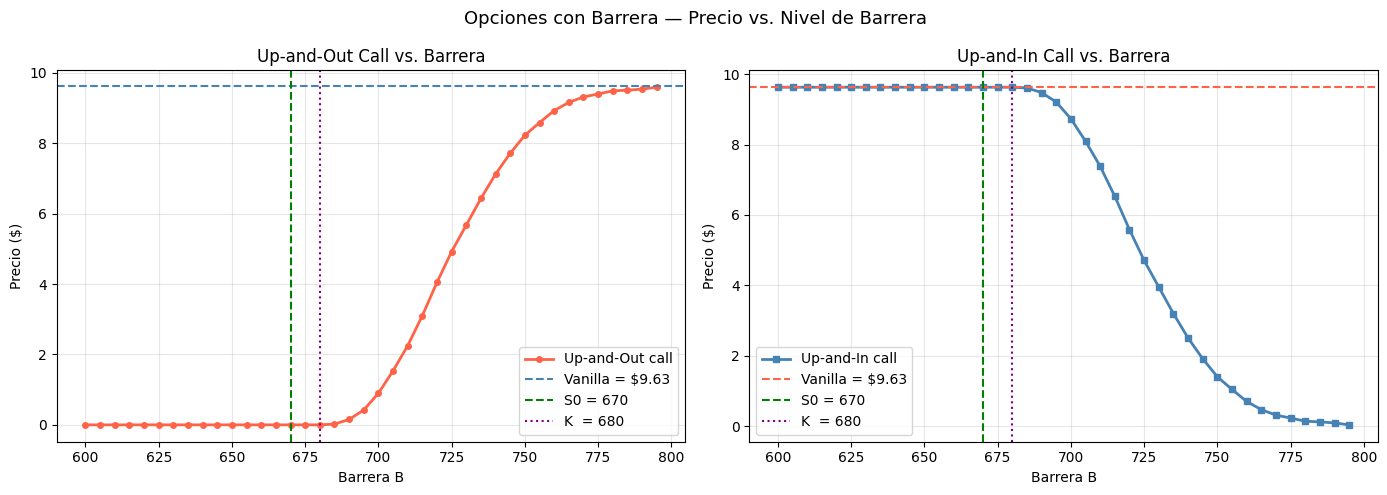

In [6]:
B_range     = np.arange(600, 800, 5)
precios_uao = []
precios_uai = []

for b in B_range:
    s_max_b = S_paths.max(axis=1)
    precio_out = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b < b)
    precio_in  = np.exp(-r*T) * np.maximum(ST - K, 0) * (s_max_b >= b)
    precios_uao.append(precio_out.mean())
    precios_uai.append(precio_in.mean())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Up-and-Out
axes[0].plot(B_range, precios_uao, color='tomato', linewidth=2, marker='o', markersize=4,
             label='Up-and-Out call')
axes[0].axhline(europea.mean(), color='steelblue', linestyle='--',
                linewidth=1.5, label=f'Vanilla = ${europea.mean():.2f}')
axes[0].axvline(S0, color='green',  linestyle='--', label=f'S0 = {S0}')
axes[0].axvline(K,  color='purple', linestyle=':',  label=f'K  = {K}')
axes[0].set_xlabel('Barrera B')
axes[0].set_ylabel('Precio ($)')
axes[0].set_title('Up-and-Out Call vs. Barrera')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Up-and-In
axes[1].plot(B_range, precios_uai, color='steelblue', linewidth=2, marker='s', markersize=4,
             label='Up-and-In call')
axes[1].axhline(europea.mean(), color='tomato', linestyle='--',
                linewidth=1.5, label=f'Vanilla = ${europea.mean():.2f}')
axes[1].axvline(S0, color='green',  linestyle='--', label=f'S0 = {S0}')
axes[1].axvline(K,  color='purple', linestyle=':',  label=f'K  = {K}')
axes[1].set_xlabel('Barrera B')
axes[1].set_ylabel('Precio ($)')
axes[1].set_title('Up-and-In Call vs. Barrera')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Opciones con Barrera — Precio vs. Nivel de Barrera', fontsize=13)
plt.tight_layout()
plt.show()

---
## Pregunta 3: Si la barrera B está muy cerca de S0, el up-and-out call casi no vale nada. ¿Por qué? ¿Y si la barrera está muy lejos?



La gráfica anterior lo ilustra perfectamente. Analicemos los dos extremos:

#### Barrera muy cerca de S₀ (B ↓ S₀)

Cuando $B \approx S_0$, **casi cualquier trayectoria que suba un poco toca inmediatamente la barrera** y la opción queda cancelada. La probabilidad de que el activo termine ITM sin tocar nunca la barrera es ínfima. Formalmente:

$$\Pr(S_{\max} < B \text{ y } S_T > K) \approx 0 \quad \text{cuando } B \to S_0$$

Pero para que una call gane dinero, necesitamos $S_T > K > S_0$, lo que implica que el precio subió... y casi seguro tocó la barrera en el camino. Por tanto:

$$C_{\text{Up-and-Out}} \to 0 \quad \text{cuando } B \to S_0^+$$

#### Barrera muy lejos de S₀ (B → ∞)

Cuando $B$ es muy grande, la probabilidad de que el activo toque la barrera durante la vida de la opción es prácticamente nula:

$$\Pr(S_{\max} \geq B) \approx 0 \quad \text{cuando } B \to \infty$$

La condición knock-out nunca se activa, así que la Up-and-Out se comporta **exactamente como una call vanilla**:

$$C_{\text{Up-and-Out}} \to C_{\text{Vanilla}} \quad \text{cuando } B \to \infty$$

Esto también lo confirma la paridad: si $C_{\text{Up-and-Out}} \to C_{\text{Vanilla}}$, entonces $C_{\text{Up-and-In}} \to 0$ (la barrera nunca se toca, luego la opción de activación nunca se activa).

#### Resumen visual

| Barrera B | Up-and-Out | Up-and-In |
|-----------|------------|----------|
| B ≈ S₀   | ≈ 0        | ≈ Vanilla |
| B moderada | Intermedio | Intermedio |
| B → ∞    | ≈ Vanilla  | ≈ 0       |

---
## Gráfica adicional: Comparación Asiática vs. Vanilla para distintas volatilidades

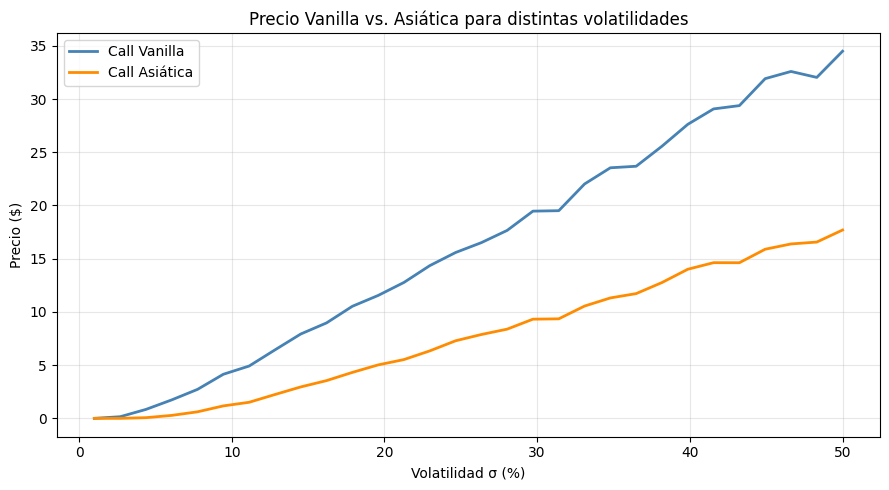

Nota: Para σ→0, ambas opciones convergen al mismo precio (el activo crece deterministamente).


In [7]:
# ¿Cuándo convergen asiática y vanilla? — Variando sigma
sigma_range = np.linspace(0.01, 0.50, 30)
precios_van = []
precios_asi = []

for s in sigma_range:
    Z_s      = np.random.standard_normal((5000, N))
    ret_s    = (r - 0.5*s**2)*dt + s*np.sqrt(dt)*Z_s
    paths_s  = S0 * np.exp(np.cumsum(ret_s, axis=1))
    paths_s  = np.insert(paths_s, 0, S0, axis=1)
    ST_s     = paths_s[:, -1]
    Sm_s     = paths_s.mean(axis=1)
    precios_van.append(np.exp(-r*T)*np.maximum(ST_s - K, 0).mean())
    precios_asi.append(np.exp(-r*T)*np.maximum(Sm_s - K, 0).mean())

plt.figure(figsize=(9, 5))
plt.plot(sigma_range*100, precios_van, color='steelblue', linewidth=2, label='Call Vanilla')
plt.plot(sigma_range*100, precios_asi, color='darkorange', linewidth=2, label='Call Asiática')
plt.xlabel('Volatilidad σ (%)')
plt.ylabel('Precio ($)')
plt.title('Precio Vanilla vs. Asiática para distintas volatilidades')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Nota: Para σ→0, ambas opciones convergen al mismo precio (el activo crece deterministamente).")

---
## Pregunta 4: ¿Por qué Monte Carlo es especialmente apropiado para opciones exóticas? ¿Cuál es su limitación principal vs. soluciones analíticas?



#### ¿Por qué Monte Carlo es la herramienta ideal para opciones exóticas?

**1. Flexibilidad de path-dependence**  
Las opciones exóticas como la asiática y las de barrera dependen de **toda la trayectoria del precio**, no solo del valor final. Monte Carlo simula trayectorias completas, por lo que naturalmente captura:
- El promedio histórico ($\bar{S}$) → asiáticas
- El máximo/mínimo alcanzado → barreras knock-in/knock-out
- El valor en fechas específicas → opciones lookback, cliquet, etc.

Las fórmulas analíticas tipo Black-Scholes solo existen bajo supuestos muy restrictivos (GBM, barrera constante, promedio aritmético aproximado). Para casos más generales, no hay solución cerrada.

**2. Alta dimensionalidad**  
Monte Carlo escala bien a problemas con muchos activos subyacentes (opciones sobre canastas, CDOs) o muchas fechas de observación. Los métodos de árboles o diferencias finitas colapsan exponencialmente en dimensiones altas.

**3. Facilidad de implementación**  
Cambiar el payoff es tan sencillo como modificar una línea de código. La misma infraestructura de simulación sirve para decenas de estructuras exóticas distintas.

**4. Incorporación de modelos complejos**  
Modelos con volatilidad estocástica (Heston), saltos (Merton), tasas estocásticas o correlaciones complejas son difíciles de resolver analíticamente pero relativamente fáciles de simular.

---

#### Limitación principal: velocidad de convergencia

El error estándar de Monte Carlo cae como:

$$\text{Error} \sim \frac{\sigma_{\text{payoff}}}{\sqrt{M}}$$

Para reducir el error a la mitad, **se necesita cuadruplicar el número de simulaciones**. Esto implica:

| Método | Convergencia | Complejidad |
|--------|-------------|-------------|
| Monte Carlo | $O(1/\sqrt{M})$ | Alta en M |
| Black-Scholes (analítico) | Exacto | Instantáneo |
| Árbol binomial | $O(1/N)$ o $O(1/N^2)$ | Moderada |
| Diferencias finitas | $O(\Delta t^2 + \Delta S^2)$ | Moderada |

**Otras limitaciones importantes:**
- El error de Monte Carlo es **estocástico**: dos corridas del mismo modelo dan precios distintos.
- Para ejercicio anticipado (opciones americanas), Monte Carlo requiere técnicas adicionales complejas (Longstaff-Schwartz, árboles de regresión).
- Las griegas (delta, gamma, vega) son menos estables y requieren más simulaciones o técnicas especiales (pathwise derivatives, likelihood ratio method).

En resumen Monte Carlo sacrifica velocidad y precisión puntual a cambio de flexibilidad universal. Es la navaja suiza de los derivados exóticos.

---
## Tabla resumen de resultados

In [8]:
print("=" * 55)
print(f"{'RESUMEN DE PRECIOS':^55}")
print(f"{'S0=' + str(S0) + '  K=' + str(K) + '  r=' + str(r) + '  σ=' + str(sigma) + '  T=31d':^55}")
print("=" * 55)
print(f"{'Instrumento':<30} {'Precio':>10}")
print("-" * 55)
print(f"{'Call Vanilla (Black-Scholes)':<30} ${bs_call:>9.4f}")
print(f"{'Call Vanilla (Monte Carlo)':<30} ${europea.mean():>9.4f}")
print(f"{'Call Asiática (Monte Carlo)':<30} ${asiatica.mean():>9.4f}")
print(f"{'Up-and-Out (B=710)':<30} ${call_up_and_out.mean():>9.4f}")
print(f"{'Up-and-In  (B=710)':<30} ${call_up_and_in.mean():>9.4f}")
print(f"{'Out + In   (verificación)':<30} ${call_up_and_out.mean() + call_up_and_in.mean():>9.4f}")
print("=" * 55)
print(f"{'Prima anticipada (Vanilla-Asiática)':<30} ${europea.mean() - asiatica.mean():>9.4f}")
print("=" * 55)

                  RESUMEN DE PRECIOS                   
         S0=670  K=680  r=0.04  σ=0.17  T=31d          
Instrumento                        Precio
-------------------------------------------------------
Call Vanilla (Black-Scholes)   $   9.5820
Call Vanilla (Monte Carlo)     $   9.6304
Call Asiática (Monte Carlo)    $   4.0437
Up-and-Out (B=710)             $   2.2478
Up-and-In  (B=710)             $   7.3826
Out + In   (verificación)      $   9.6304
Prima anticipada (Vanilla-Asiática) $   5.5867
